In [10]:
import pandas as pd

# Correction : pas d'espace avant l'extension .csv
train_df = pd.read_csv('Data/UNSW_NB15_training-set.csv')
test_df = pd.read_csv('Data/UNSW_NB15_testing-set.csv')

# Suppression de la colonne 'id' si elle existe
train_df.drop(columns=['id'], inplace=True, errors='ignore')
test_df.drop(columns=['id'], inplace=True, errors='ignore')

In [11]:
# 2. ENCODAGE DES VARIABLES CATÉGORIELLES
from sklearn.preprocessing import OneHotEncoder

cat_columns = ['proto', 'service', 'state']


encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_encoded = encoder.fit_transform(train_df[cat_columns])
test_encoded = encoder.transform(test_df[cat_columns])


train_encoded_df = pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out(cat_columns))
test_encoded_df = pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out(cat_columns))


train_df = pd.concat([train_df.drop(columns=cat_columns), train_encoded_df], axis=1)
test_df = pd.concat([test_df.drop(columns=cat_columns), test_encoded_df], axis=1)

print(f"Encodage terminé. Nouvelles dimensions : {train_df.shape}")

Encodage terminé. Nouvelles dimensions : (175341, 196)


In [12]:
# 3. NORMALISATION
from sklearn.preprocessing import StandardScaler

# Identifier les colonnes numériques (exclure la cible)
num_columns = [col for col in train_df.columns if col not in ['label', 'attack_cat']]


scaler = StandardScaler()
train_df[num_columns] = scaler.fit_transform(train_df[num_columns])
test_df[num_columns] = scaler.transform(test_df[num_columns])

print("Normalisation terminée")

Normalisation terminée


In [13]:
# 4. SÉPARATION DES FEATURES ET LABELS
X_train = train_df.drop(columns=['label', 'attack_cat'])
y_train = train_df['label'].astype(int)  # Assurer un format correct
X_test = test_df.drop(columns=['label', 'attack_cat'])
y_test = test_df['label'].astype(int)

C:\Users\oumaima\AppData\Local\Temp\ipykernel_62892\1028018136.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='coolwarm')


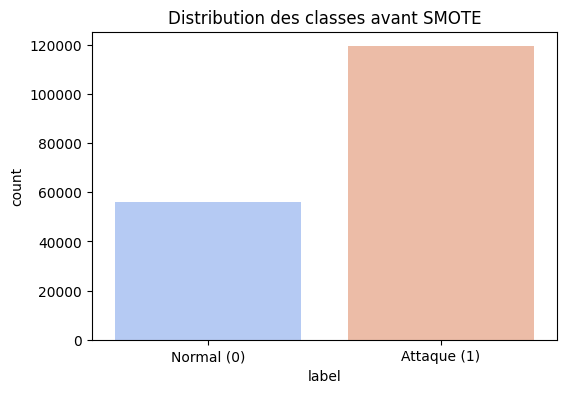

Distribution des classes dans train:
  - Normal (0): 56000 samples
  - Attaque (1): 119341 samples
  - Ratio attaque/normal: 213.11%


In [14]:
# 5. ANALYSE DE LA DISTRIBUTION DES CLASSES
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='coolwarm')
plt.title("Distribution des classes avant SMOTE")
plt.xticks([0, 1], ['Normal (0)', 'Attaque (1)'])  # Optionnel : ajouter les labels
plt.show()

# Afficher les chiffres exacts
print(f"Distribution des classes dans train:")
print(f"  - Normal (0): {(y_train == 0).sum()} samples")
print(f"  - Attaque (1): {(y_train == 1).sum()} samples")
print(f"  - Ratio attaque/normal: {(y_train == 1).sum() / (y_train == 0).sum():.2%}")

C:\Users\oumaima\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\oumaima\AppData\Local\Temp\ipykernel_62892\2870626501.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, palette='coolwarm')


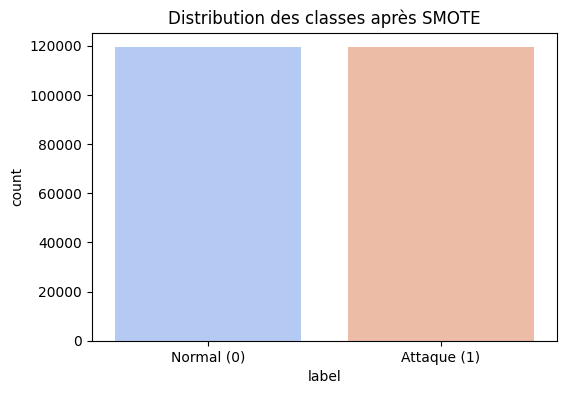

Distribution des classes après SMOTE:
  - Normal (0): 119341 samples
  - Attaque (1): 119341 samples
  - Ratio: 100.00%


In [15]:
# 6. APPLICATION DE SMOTE POUR EQUILIBRER LES CLASSES
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled, palette='coolwarm')
plt.title("Distribution des classes après SMOTE")
plt.xticks([0, 1], ['Normal (0)', 'Attaque (1)'])
plt.show()

# Afficher la nouvelle distribution
print(f"Distribution des classes après SMOTE:")
print(f"  - Normal (0): {(y_train_resampled == 0).sum()} samples")
print(f"  - Attaque (1): {(y_train_resampled == 1).sum()} samples")
print(f"  - Ratio: {(y_train_resampled == 1).sum() / (y_train_resampled == 0).sum():.2%}")

In [16]:
# 7. RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test)  # Correction : x_test → X_test (majuscule)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.885330126803673


In [17]:
# 8. AUTOENCODEUR
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

scaler_ae = MinMaxScaler()
X_train_scaled = scaler_ae.fit_transform(X_train_resampled)  
X_test_scaled = scaler_ae.transform(X_test)
input_dim = X_train_scaled.shape[1] 

autoencoder = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(input_dim, activation='sigmoid')  
])  

autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=50, batch_size=256, validation_data=(X_test_scaled, X_test_scaled), verbose=1)

# Visualisation des erreurs de reconstruction
reconstruction_error = np.mean(np.abs(autoencoder.predict(X_test_scaled) - X_test_scaled), axis=1)
sns.histplot(reconstruction_error, bins=50, kde=True, color='red')
plt.title("Distribution des erreurs de reconstruction de l'autoencodeur")
plt.xlabel("Erreur de reconstruction")
plt.ylabel("Fréquence")
plt.show()

ModuleNotFoundError: No module named 'tensorflow.python'

In [ ]:
# 9. CNN-LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Flatten, Dense

# Reshape pour CNN-LSTM (samples, timesteps, features)
X_train_seq = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_seq = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Forme X_train_seq: {X_train_seq.shape}")
print(f"Forme X_test_seq: {X_test_seq.shape}")

cnn_lstm = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_seq.shape[1], 1)),
    LSTM(50, return_sequences=False),  # Correction: return_sequences=False pour éviter la sortie 3D
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1, activation='sigmoid')
])  

cnn_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_lstm.fit(X_train_seq, y_train_resampled, epochs=10, batch_size=64, validation_data=(X_test_seq, y_test))  